# 15 – Mini Assessment

### What is EDA?

EDA stands for Exploratory Data Analysis. It is the process of analyzing a dataset to understand its structure, identify missing values and duplicates, detect outliers, analyze distributions, and find relationships or patterns before building a Machine Learning model.

In [5]:
#EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
#1. Load the Dataset
df = pd.read_csv("cancer_prediction_uncleaned.csv")
print(df.head())

# Understanding dataset
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

  Patient_ID   Age  Gender  Tumor_Size_cm  Cell_Count  Weight_kg Smoking  \
0      P1001  63.0  Female            0.6          53      105.9     Yes   
1      P1002  53.0    Male            2.0          33       53.9      No   
2      P1003  39.0  Female            5.8          88       67.2     Yes   
3      P1004  67.0  female            6.4          68       52.4      No   
4      P1005  32.0    Male            5.0          41      105.1      No   

  Family_History Pain Cancer  
0             No  Yes     No  
1            Yes  Yes     No  
2            Yes   No    Yes  
3             No   No    Yes  
4            Yes  Yes     No  
Rows: 39
Columns: 10


In [16]:
# structure
df.info()
# data types
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient_ID      39 non-null     object 
 1   Age             37 non-null     float64
 2   Gender          39 non-null     object 
 3   Tumor_Size_cm   38 non-null     float64
 4   Cell_Count      39 non-null     int64  
 5   Weight_kg       37 non-null     float64
 6   Smoking         38 non-null     object 
 7   Family_History  38 non-null     object 
 8   Pain            39 non-null     object 
 9   Cancer          39 non-null     object 
dtypes: float64(3), int64(1), object(6)
memory usage: 3.2+ KB


Patient_ID         object
Age               float64
Gender             object
Tumor_Size_cm     float64
Cell_Count          int64
Weight_kg         float64
Smoking            object
Family_History     object
Pain               object
Cancer             object
dtype: object

In [20]:
#null values
df.isnull().sum().sum()

# duplicates
df.duplicated().sum()

np.int64(0)

### Why is EDA performed before Machine Learning?

EDA is performed before Machine Learning to understand the dataset, identify missing values, duplicates, outliers, data types, distributions, correlations, and patterns. It helps us clean and prepare the data properly before training the Machine Learning model.

### Difference between univariate, bivariate, and multivariate analysis.


In [25]:
# Univariate
df["Age"].describe()

count     37.000000
mean      52.729730
std       17.925228
min       26.000000
25%       40.000000
50%       49.000000
75%       64.000000
max      120.000000
Name: Age, dtype: float64

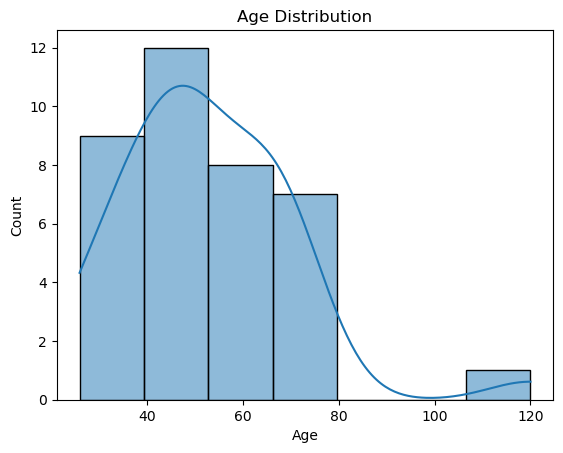

In [32]:
sns.histplot(df["Age"], kde = True)

plt.title("Age Distribution")
plt.show()

In [ ]:
#Bivariate
Analyzes two variables to understand their relationship.

Example:

Is tumor size related to cancer?


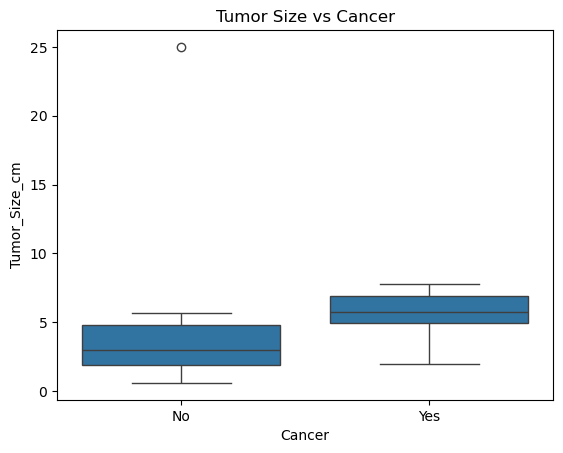

In [33]:
sns.boxplot(data=df, x="Cancer", y= "Tumor_Size_cm")
plt.title("Tumor Size vs Cancer")
plt.show()

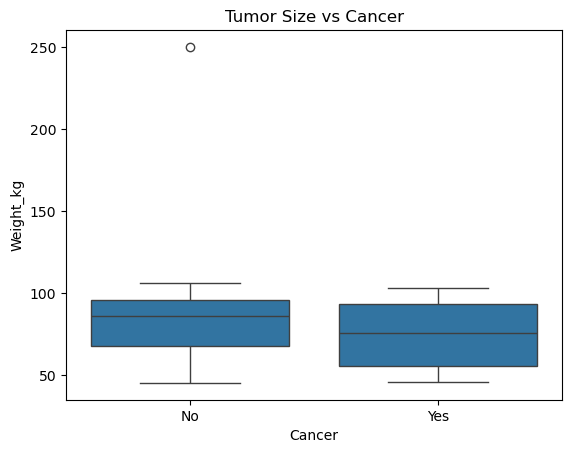

In [34]:
sns.boxplot(data=df, x="Cancer", y= "Weight_kg")
plt.title("Tumor Size vs Cancer")
plt.show()

### Multivariate Analysis

Analyzes three or more variables together.

Example:

How are tumor size, cell count, age, and cancer status related?


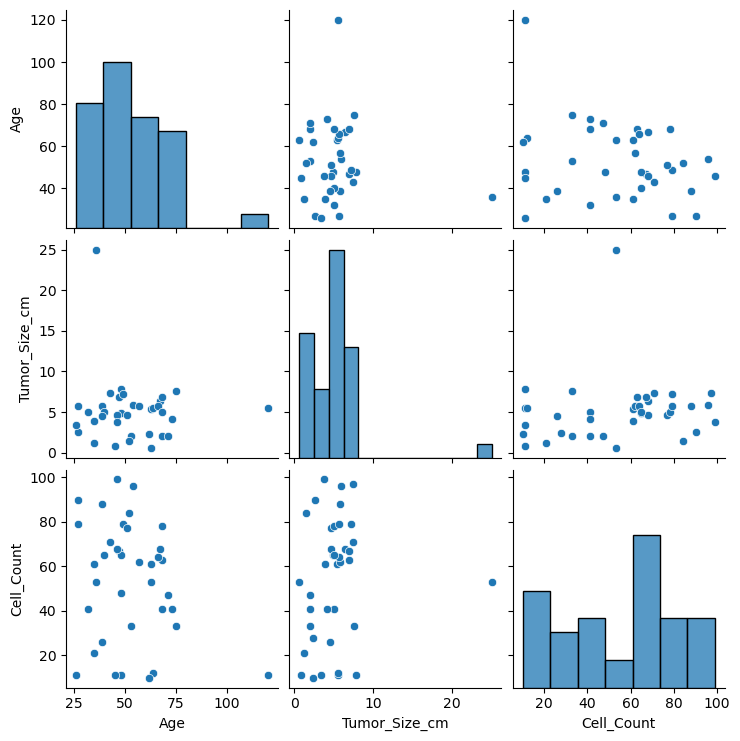

In [36]:
sns.pairplot(df[["Age", "Tumor_Size_cm", "Cell_Count"]])

plt.show()

### How do you identify missing values?


Missing values are empty or unavailable values in a dataset.

We identify missing values to know which columns contain empty data before performing Machine Learning.

In Pandas, we commonly use:

isnull()
isna()
sum()

In [40]:
import pandas as pd

df = pd.read_csv("cancer_prediction_uncleaned.csv")

print(df.isnull().sum())
print(df.isnull().sum().sum())

Patient_ID        0
Age               2
Gender            0
Tumor_Size_cm     1
Cell_Count        0
Weight_kg         2
Smoking           1
Family_History    1
Pain              0
Cancer            0
dtype: int64
7


### How do you identify duplicate records?


0


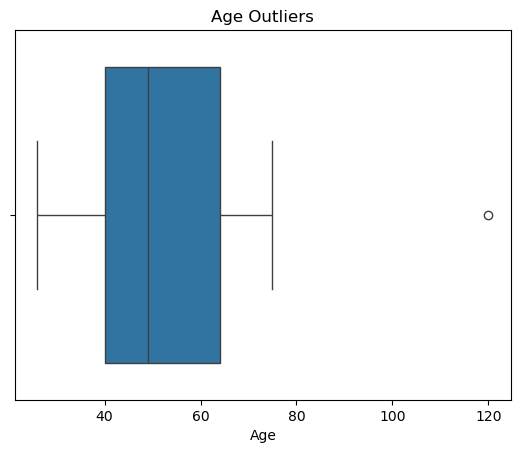

In [54]:
print(df.duplicated().sum())

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["Age"])

plt.title("Age Outliers")
plt.show()

### What is an Outlier?  Explain the IQR method.

An outlier is a data value that is significantly different from most of the other values in a dataset.

An outlier is an observation that is significantly different from the majority of the data. We can detect outliers using methods such as IQR or Z-score. Before removing an outlier, we should determine whether it is a genuine observation or a data-quality issue.

In [56]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: 4.0
Upper Limit: 100.0


### What is Skewness?
Answer

Skewness measures how much a numerical data distribution is asymmetric.

In simple words, it tells us whether the data is spread more toward the left or right side.

In [57]:
df["Age"].skew()

np.float64(1.3388171099035344)

In [58]:
numerical_columns = df.select_dtypes(
    include="number"
).columns

df[numerical_columns].skew()

Age              1.338817
Tumor_Size_cm    3.635106
Cell_Count      -0.223581
Weight_kg        3.172905
dtype: float64

### What is Correlation?
Answer

Correlation measures the strength and direction of the relationship between two numerical variables.

The correlation value usually ranges from -1 to +1.

In [59]:
numerical_columns = df.select_dtypes(
    include="number"
).columns

correlation = df[numerical_columns].corr()

print(correlation)

                    Age  Tumor_Size_cm  Cell_Count  Weight_kg
Age            1.000000      -0.080042   -0.235042  -0.327995
Tumor_Size_cm -0.080042       1.000000    0.144042   0.160010
Cell_Count    -0.235042       0.144042    1.000000   0.133505
Weight_kg     -0.327995       0.160010    0.133505   1.000000


### Difference Between Correlation and Causation

In [61]:
import pandas as pd

df = pd.read_csv("cancer_prediction_uncleaned.csv")

correlation = df["Tumor_Size_cm"].corr(
    df["Cell_Count"]
)

print("Correlation:", correlation)

Correlation: 0.14404184434090622


### What is Multicollinearity?

Multicollinearity occurs when two or more independent variables (features) are highly correlated with each other.

Multicollinearity occurs when two or more independent features are highly correlated with each other. It can make model coefficients unstable and make it difficult to understand the individual effect of each feature.

### How do you identify class imbalance?

Class imbalance occurs when the classes in a classification target variable are not distributed equally.

For example, if our cancer dataset contains:

Cancer = No   → 50 patients
Cancer = Yes  → 10 patients


In [62]:
import pandas as pd

df = pd.read_csv("cancer_prediction_uncleaned.csv")

df["Cancer"].value_counts()

Cancer
Yes    22
No     17
Name: count, dtype: int64

In [63]:
df["Cancer"].value_counts(normalize=True) * 100

Cancer
Yes    56.410256
No     43.589744
Name: proportion, dtype: float64

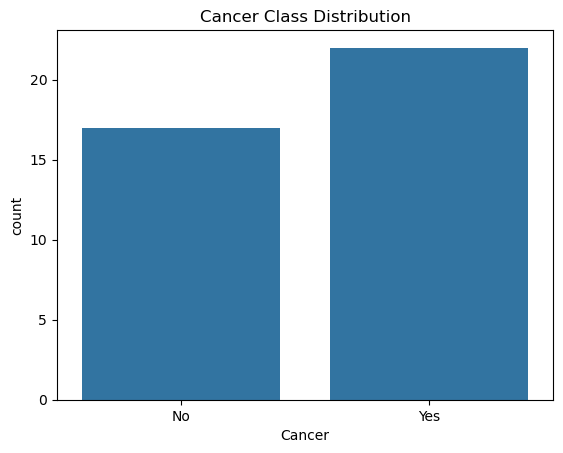

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    data=df,
    x="Cancer"
)

plt.title("Cancer Class Distribution")
plt.show()

#Class imbalance occurs when the classes in a classification target are unequally distributed. I identify it by checking class counts and percentages using value_counts(), and I can visualize it using a count plot.

### Why should outliers not always be removed?

In [65]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 39
Columns: 10


In [66]:
#Detect outliers using IQR.

numerical_columns = df.select_dtypes(include="number").columns

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]

print(df)

   Patient_ID   Age  Gender  Tumor_Size_cm  Cell_Count  Weight_kg Smoking  \
0       P1001  63.0  Female            0.6          53      105.9     Yes   
1       P1002  53.0    Male            2.0          33       53.9      No   
2       P1003  39.0  Female            5.8          88       67.2     Yes   
3       P1004  67.0  female            6.4          68       52.4      No   
4       P1005  32.0    Male            5.0          41      105.1      No   
6       P1007  63.0    Male            5.4          61       61.8     Yes   
7       P1008  43.0    Male            7.4          71       87.9      No   
8       P1009  47.0    Male            6.9          67       98.1     NaN   
9       P1010  35.0    Male            3.9          61       81.1      No   
10      P1011  35.0    Male            1.2          21       79.4     Yes   
13      P1014  64.0    Male            5.5          12      103.3     Yes   
15      P1016  27.0  Female            2.6          90       86.2     Yes   

In [67]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 31
Columns: 10


### Create a correlation heatmap.
A correlation heatmap is used to visually show the correlation between numerical variables.A correlation heatmap is a visualization used to display the correlation between numerical variables. It helps us quickly identify strong positive or negative relationships and potential multicollinearity between features.

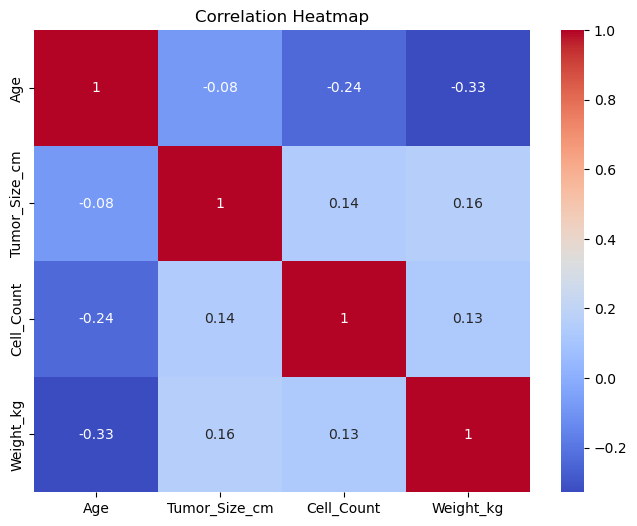

In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("cancer_prediction_uncleaned.csv")

# Select numerical columns
numerical_columns = df.select_dtypes(
    include="number"
).columns

# Calculate correlation
correlation = df[numerical_columns].corr()

# Create heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

### Generate a complete EDA summary.
  A complete EDA summary describes the dataset's structure, data types, missing values, duplicates, numerical and categorical features, outliers, distributions, correlations, target distribution, and important patterns. The findings are then used to decide the appropriate preprocessing steps before Machine Learning.

In [ ]:
| Plot                   | Data Type                    | Analysis                   | Example                 | Purpose                                          |
| ---------------------- | ---------------------------- | -------------------------- | ----------------------- | ------------------------------------------------ |
| **Histogram**          | Numerical                    | **Univariate**             | Age                     | Distribution of one numerical variable           |
| **KDE Plot**           | Numerical                    | **Univariate**             | Age                     | Shape of distribution                            |
| **Boxplot**            | Numerical                    | **Univariate**             | Age                     | Distribution + outliers                          |
| **Countplot**          | Categorical                  | **Univariate**             | Gender                  | Frequency of categories                          |
| **Barplot**            | Categorical/Numerical        | **Bivariate**              | Gender vs Average Age   | Compare numerical values across categories       |
| **Pie Chart**          | Categorical                  | **Univariate**             | Cancer Yes/No           | Show category proportions                        |
| **Scatterplot**        | Numerical + Numerical        | **Bivariate**              | Age vs Tumor Size       | Relationship between two numerical variables     |
| **Line Plot**          | Numerical + Numerical / Time | **Bivariate**              | Date vs Sales           | Trend over time                                  |
| **Boxplot**            | Categorical + Numerical      | **Bivariate**              | Cancer vs Age           | Compare numerical distribution across categories |
| **Violin Plot**        | Categorical + Numerical      | **Bivariate**              | Cancer vs Tumor Size    | Compare distributions                            |
| **Countplot with hue** | Categorical + Categorical    | **Bivariate**              | Smoking vs Cancer       | Compare category counts                          |
| **Heatmap**            | Numerical + Numerical        | **Bivariate/Multivariate** | Correlation             | Show correlations                                |
| **Pairplot**           | Multiple Numerical           | **Multivariate**           | Age, Weight, Tumor Size | Relationships among many variables               |


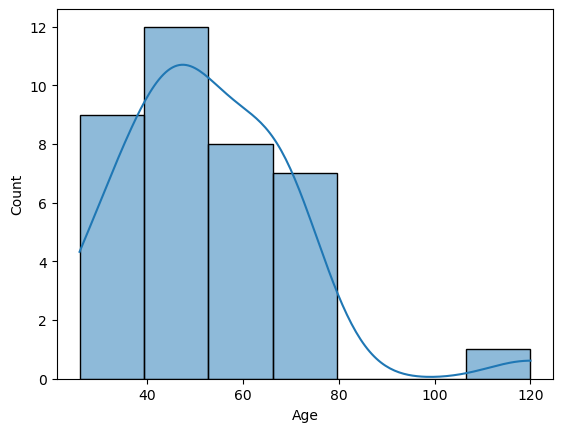

In [70]:
#Histogram

sns.histplot(df["Age"], kde=True)
plt.show()

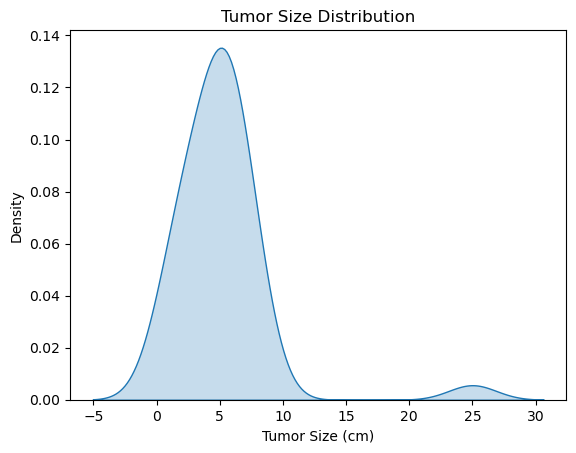

In [71]:
# KDE Plot

# Numerical + Univariate

# Example: Tumor_Size_cm

sns.kdeplot(df["Tumor_Size_cm"], fill=True)


plt.title("Tumor Size Distribution")
plt.xlabel("Tumor Size (cm)")
plt.show()

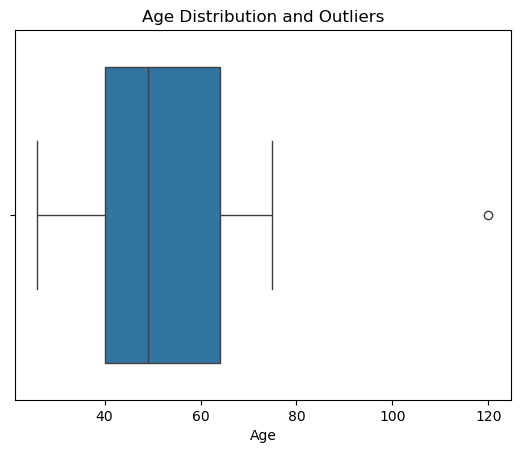

In [72]:
# Boxplot – Numerical Univariate

# Numerical + Univariate

# Example: Age

sns.boxplot(x=df["Age"])


plt.title("Age Distribution and Outliers")
plt.xlabel("Age")
plt.show()

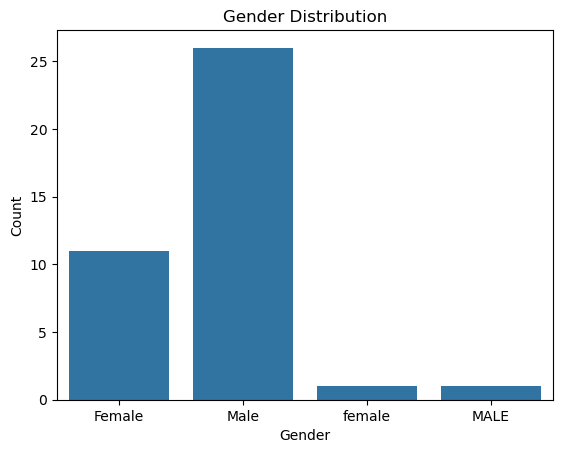

In [74]:
# Countplot

# Categorical + Univariate

# Example: Gender

sns.countplot(data=df, x="Gender")


plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

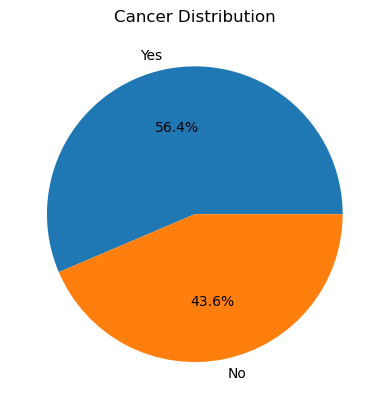

In [75]:
# Pie Chart

# Categorical + Univariate

# Example: Cancer

df["Cancer"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)


plt.title("Cancer Distribution")
plt.ylabel("")
plt.show()

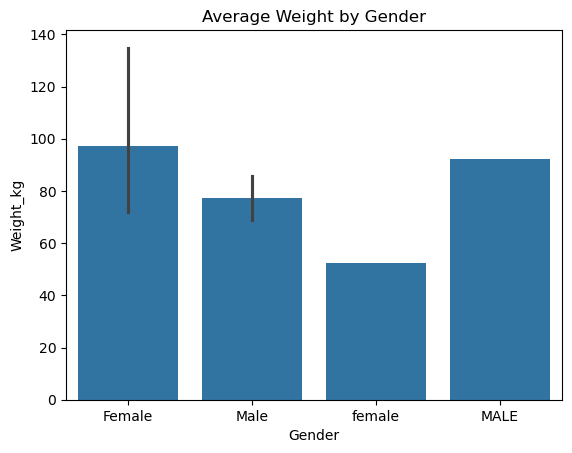

In [76]:
# Barplot

# Categorical + Numerical → Bivariate

# Example: Gender vs average Weight_kg

sns.barplot(
    data=df,
    x="Gender",
    y="Weight_kg"
)


plt.title("Average Weight by Gender")
plt.show()

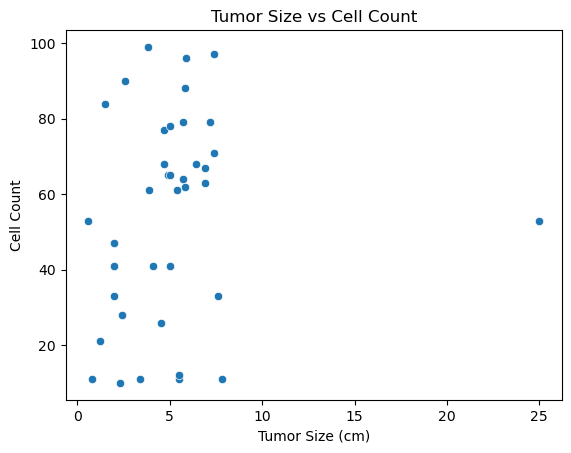

In [77]:
# Scatterplot

# Numerical + Numerical → Bivariate

# Example: Tumor_Size_cm vs Cell_Count

sns.scatterplot(
    data=df,
    x="Tumor_Size_cm",
    y="Cell_Count"
)


plt.title("Tumor Size vs Cell Count")
plt.xlabel("Tumor Size (cm)")
plt.ylabel("Cell Count")
plt.show()

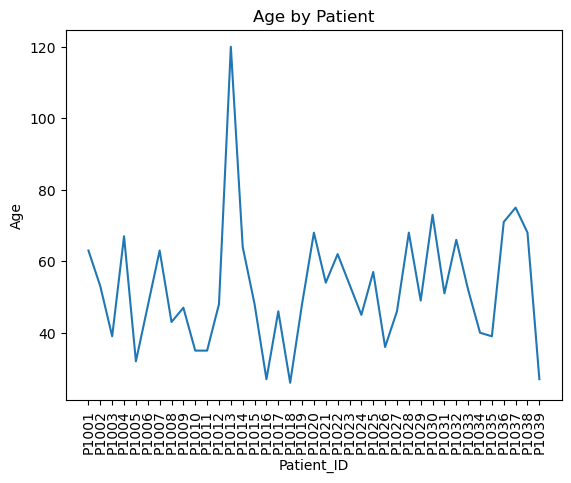

In [79]:
# Line Plot

# Numerical + Numerical → Bivariate

# For example, we can see how Age changes according to Patient_ID:

sns.lineplot(
    data=df,
    x="Patient_ID",
    y="Age"
)


plt.title("Age by Patient")
plt.xticks(rotation=90)
plt.show()


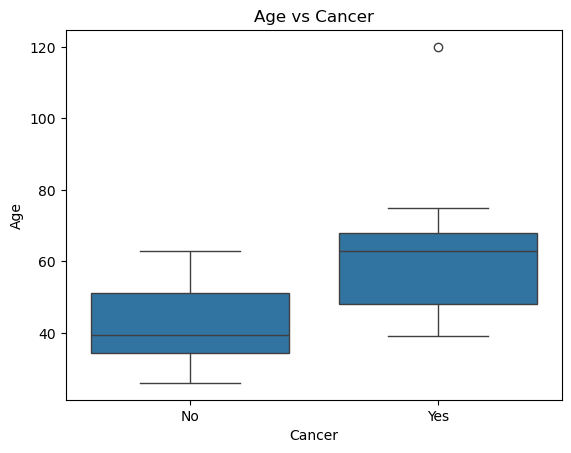

In [80]:
# Boxplot – Categorical + Numerical

# Bivariate

# Example: Cancer vs Age

sns.boxplot(
    data=df,
    x="Cancer",
    y="Age"
)


plt.title("Age vs Cancer")
plt.xlabel("Cancer")
plt.ylabel("Age")
plt.show()

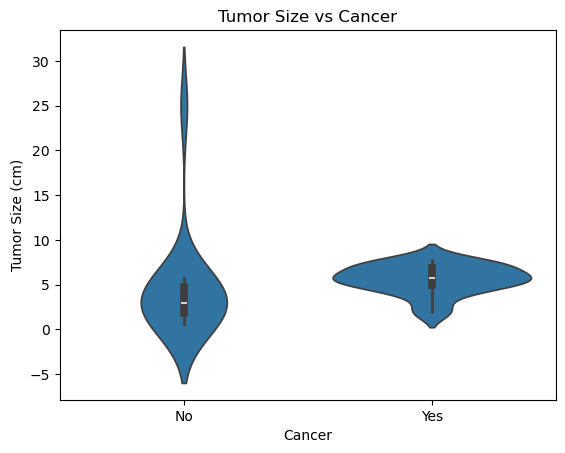

In [81]:
# Violin Plot

# Categorical + Numerical → Bivariate

# Example: Cancer vs Tumor_Size_cm

sns.violinplot(
    data=df,
    x="Cancer",
    y="Tumor_Size_cm"
)


plt.title("Tumor Size vs Cancer")
plt.xlabel("Cancer")
plt.ylabel("Tumor Size (cm)")
plt.show()

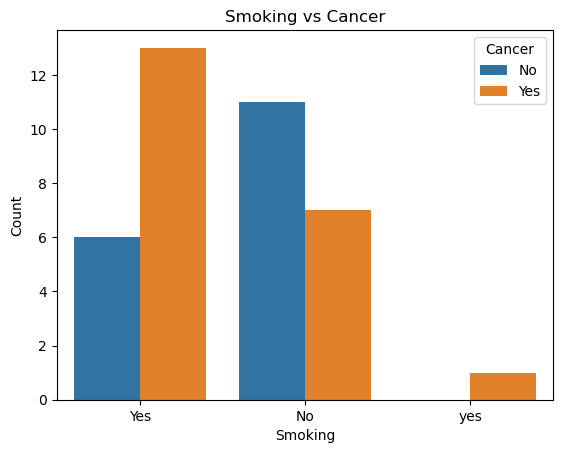

In [82]:
# Countplot with Hue

# Categorical + Categorical → Bivariate

# Example: Smoking vs Cancer

sns.countplot(
    data=df,
    x="Smoking",
    hue="Cancer"
)


plt.title("Smoking vs Cancer")
plt.xlabel("Smoking")
plt.ylabel("Count")
plt.show()

In [84]:
# Cross-tabulation

# Categorical + Categorical → Bivariate

# Example: Family_History vs Cancer

pd.crosstab(
    df["Family_History"],
    df["Cancer"]
)


Cancer,No,Yes
Family_History,,
No,10,10
Yes,7,11


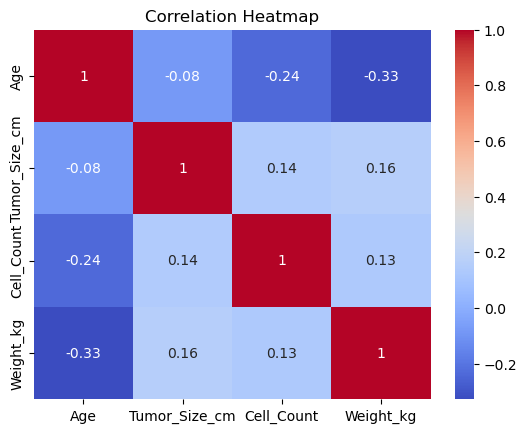

In [85]:
# Correlation Heatmap

# Numerical + Numerical → Multivariate

numerical_columns = [
    "Age",
    "Tumor_Size_cm",
    "Cell_Count",
    "Weight_kg"
]


correlation = df[numerical_columns].corr()


sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)


plt.title("Correlation Heatmap")
plt.show()

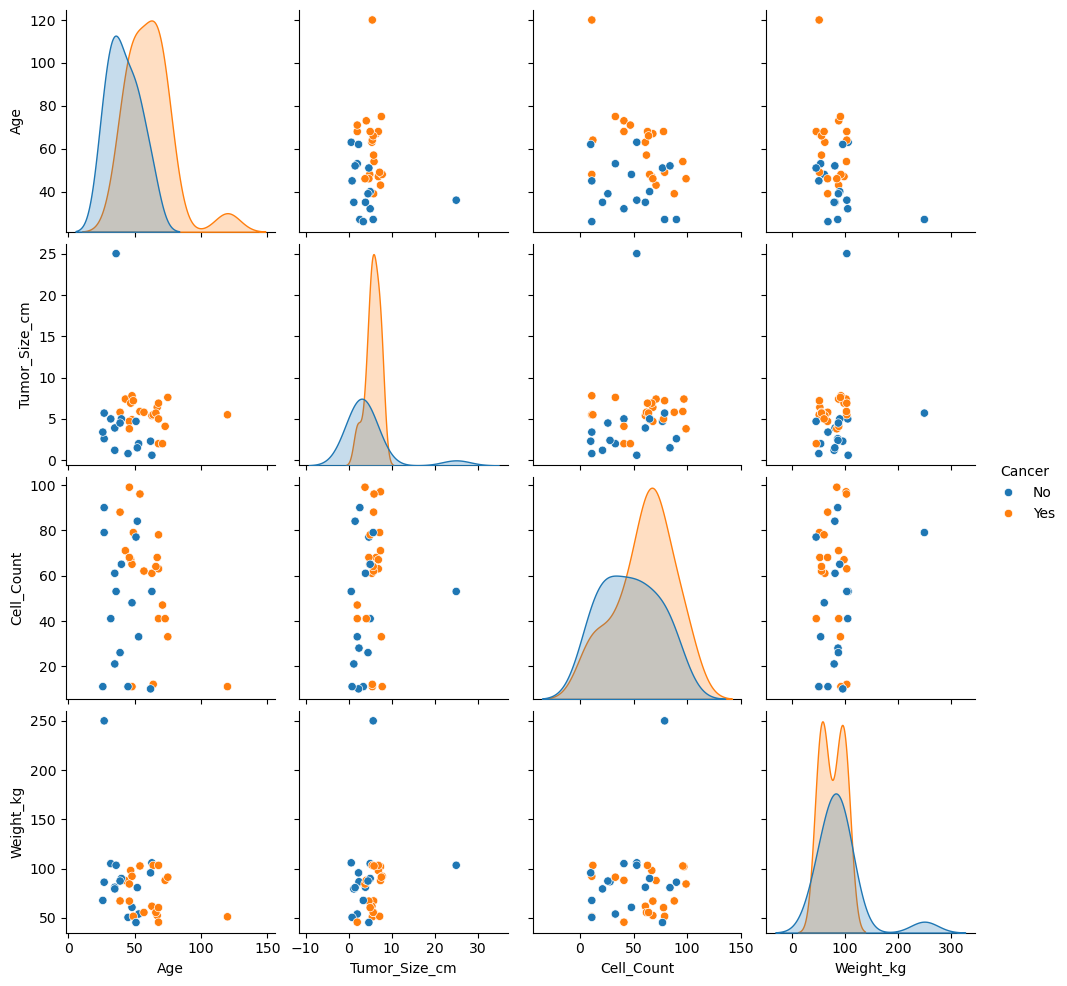

In [86]:
# Pairplot

# Multiple Variables → Multivariate

sns.pairplot(
    df[
        [
            "Age",
            "Tumor_Size_cm",
            "Cell_Count",
            "Weight_kg",
            "Cancer"
        ]
    ],
    hue="Cancer"
)


plt.show()